In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score, f1_score, precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.svm import SVC


In [4]:
data = pd.read_csv('student.csv')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Score1     100 non-null    float64
 1   Score2     100 non-null    float64
 2   Admission  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [7]:
data.describe()

,Score1,Score2,Admission
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


In [8]:
data[['Score2','Admission']].head()

,Score2,Admission
0,78.024693,0
1,43.894998,0
2,72.902198,0
3,86.308552,1
4,75.344376,1


In [46]:
data.sample(5)

,Score1,Score2,Admission
45,62.222676,52.060992,0
57,32.577200,95.598548,0
95,83.489163,48.380286,1
99,74.775893,89.529813,1
91,90.448551,87.508792,1


In [47]:
data.head()

,Score1,Score2,Admission
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [48]:
data.tail()

,Score1,Score2,Admission
95,83.489163,48.380286,1
96,42.261701,87.103851,1
97,99.315009,68.775409,1
98,55.340018,64.931938,1
99,74.775893,89.529813,1


In [49]:
data.nunique()

Score1       100
Score2       100
Admission      2
dtype: int64

In [50]:
data['Score1'].isnull().sum

<bound method Series.sum of 0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Name: Score1, Length: 100, dtype: bool>

In [51]:
data.isnull().sum()

Score1       0
Score2       0
Admission    0
dtype: int64

In [52]:
data.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool

In [21]:
data.duplicated().sum()

np.int64(0)

In [23]:
Q1 = data['Score1'].quantile(0.25)
Q3 = data['Score1'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = data[(data['Score1'] < lower_bound) | (data['Score1'] > upper_bound)]
print(outliers)


Empty DataFrame
Columns: [Score1, Score2, Admission]
Index: []


(array([2., 2., 3., 3., 1., 0., 2., 2., 2., 0., 2., 0., 1., 2., 3., 5., 0.,
        2., 3., 1., 1., 3., 4., 2., 2., 0., 4., 3., 1., 2., 1., 2., 7., 2.,
        2., 4., 1., 3., 3., 1., 0., 0., 3., 2., 1., 2., 2., 1., 2., 3.]),
 array([30.05882245, 31.45420315, 32.84958386, 34.24496457, 35.64034527,
        37.03572598, 38.43110669, 39.8264874 , 41.2218681 , 42.61724881,
        44.01262952, 45.40801022, 46.80339093, 48.19877164, 49.59415234,
        50.98953305, 52.38491376, 53.78029447, 55.17567517, 56.57105588,
        57.96643659, 59.36181729, 60.757198  , 62.15257871, 63.54795941,
        64.94334012, 66.33872083, 67.73410154, 69.12948224, 70.52486295,
        71.92024366, 73.31562436, 74.71100507, 76.10638578, 77.50176648,
        78.89714719, 80.2925279 , 81.68790861, 83.08328931, 84.47867002,
        85.87405073, 87.26943143, 88.66481214, 90.06019285, 91.45557355,
        92.85095426, 94.24633497, 95.64171568, 97.03709638, 98.43247709,
        99.8278578 ]),
 <BarContainer object

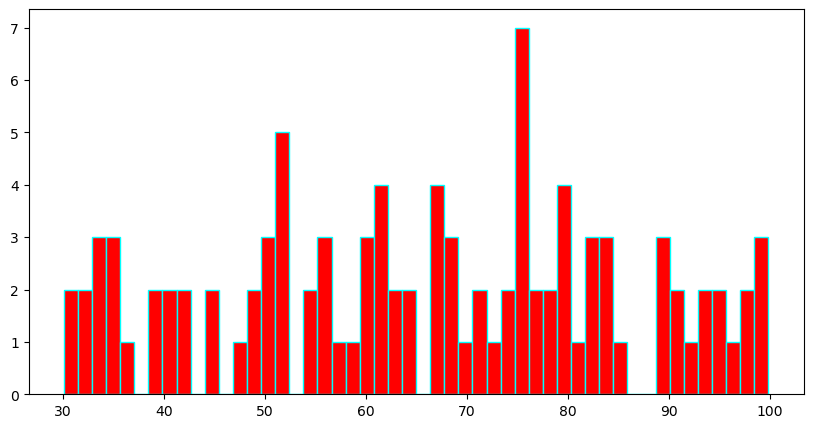

In [34]:
plt.figure(figsize=(10,5))
plt.hist(data['Score1'] , bins=50, color = 'red', edgecolor='cyan')

Text(0.5, 0, 'Admission')

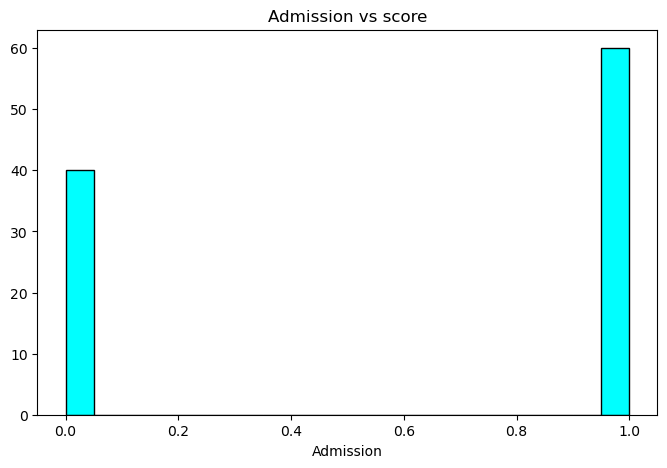

In [14]:
plt.figure(figsize=(8,5))
plt.hist(data['Admission'] , bins=20, color= 'cyan', edgecolor='black')
plt.title("Admission vs score")
plt.xlabel("Admission")

<Axes: >

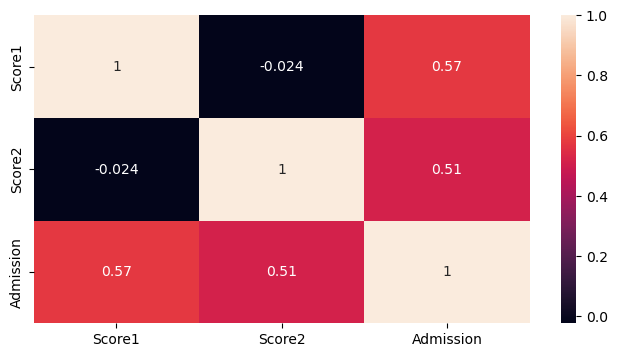

In [41]:
plt.figure(figsize=(8,4))
sns.heatmap(data.corr(),annot=True)

Text(0.5, 1.0, 'admission')

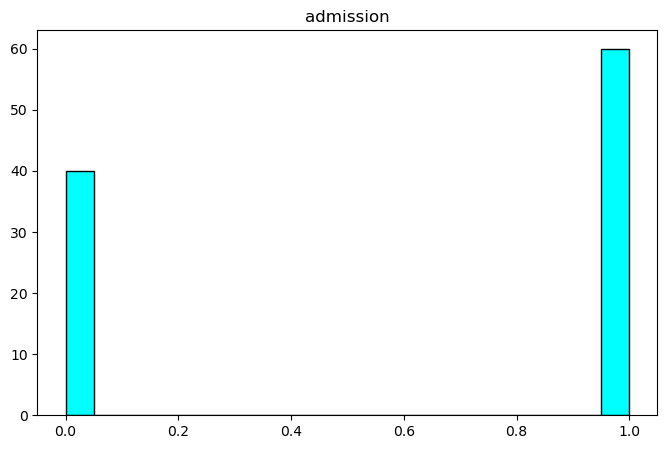

In [36]:
plt.figure(figsize=(8,5))
plt.hist(data['Admission'] , bins=20, color= 'cyan', edgecolor='black')
plt.title('admission')



In [53]:

# by spliting featurea and target
x = data[['Score1','Score2']]
y = data ['Admission']


x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 0)

#vscalling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

TRAINING 

0.8
confsn of random forest [[7 1]
 [3 9]]
Recall random forest: 0.75
Precision random forest: 0.9
F1-score random forest : 0.8181818181818182
              precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20

ROC-AUC: 0.9895833333333334


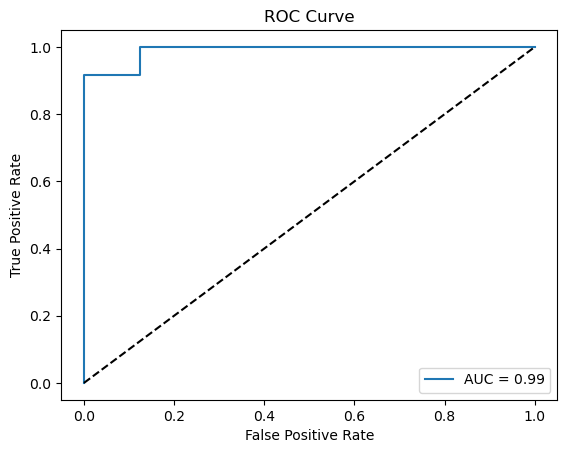

In [ ]:
# trainging by random forest
gerad = RandomForestClassifier( n_estimators = 100)
gerad.fit(x_train_scaled, y_train)
y_pred = gerad.predict(x_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(acc)

print('='*20)
cm = confusion_matrix (y_test, y_pred)
print('confsn of random forest', cm)

recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('='*20)
print("Recall random forest:", recall)
print("Precision random forest:", precision)
print("F1-score random forest :", f1)

print("="*20)
report = classification_report(y_test, y_pred)
print(report)


y_probs = GG.predict_proba(x_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC:", auc)



fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


acc of decission tree 0.75
consn of decision tree [[7 1]
 [4 8]]
Recall decision tree : 0.6666666666666666
Precision decision tree : 0.8888888888888888
F1-score decision tree: 0.7619047619047619
              precision    recall  f1-score   support

           0       0.64      0.88      0.74         8
           1       0.89      0.67      0.76        12

    accuracy                           0.75        20
   macro avg       0.76      0.77      0.75        20
weighted avg       0.79      0.75      0.75        20

ROC-AUC: 0.9895833333333334


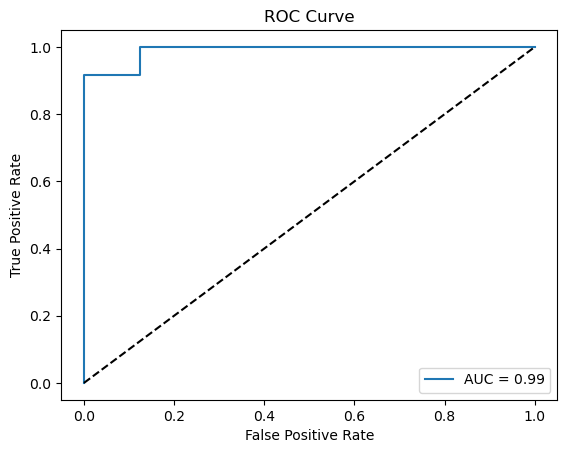

In [49]:
# trainging by decision tree
vera = DecisionTreeClassifier()
vera.fit(x_train_scaled, y_train)
y_pred = vera.predict(x_test_scaled)
acc = accuracy_score(y_test, y_pred)
print('acc of decission tree',acc)
cm = confusion_matrix (y_test, y_pred)

print("="*20)
print('consn of decision tree',cm)

recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*20)
print("Recall decision tree :", recall)
print("Precision decision tree :", precision)
print("F1-score decision tree:", f1)

print("="*20)
report = classification_report(y_test, y_pred)
print(report)



y_probs = GG.predict_proba(x_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


ac of gradient boost  0.8
confsn of gradiend [[7 1]
 [3 9]]
Recall : 0.75
Precision  : 0.9
F1-score: 0.8181818181818182
              precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20

ROC-AUC: 0.9895833333333334


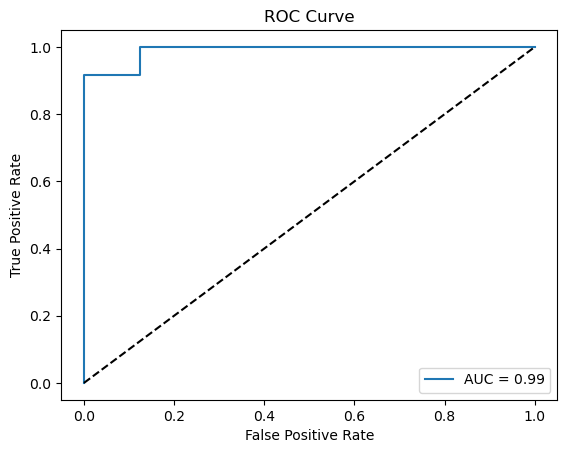

In [50]:
# train by  gradient boost
salum = GradientBoostingClassifier( n_estimators = 100)
salum.fit(x_train_scaled, y_train)
y_pred = salum.predict(x_test_scaled)
acc = accuracy_score(y_test, y_pred)
print( 'ac of gradient boost ',acc)
cm = confusion_matrix (y_test, y_pred)

print("="*20)
print('confsn of gradiend',cm) 
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*20)
print("Recall :", recall)
print("Precision  :", precision)
print("F1-score:", f1)

print("="*20)
report = classification_report(y_test, y_pred)
print(report)


y_probs = GG.predict_proba(x_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


acc of adder boost 0.85
confsn of adder [[ 7  1]
 [ 2 10]]
Recall  : 0.8333333333333334
Precision  : 0.9090909090909091
F1-score : 0.8695652173913043
              precision    recall  f1-score   support

           0       0.78      0.88      0.82         8
           1       0.91      0.83      0.87        12

    accuracy                           0.85        20
   macro avg       0.84      0.85      0.85        20
weighted avg       0.86      0.85      0.85        20

ROC-AUC: 0.9895833333333334


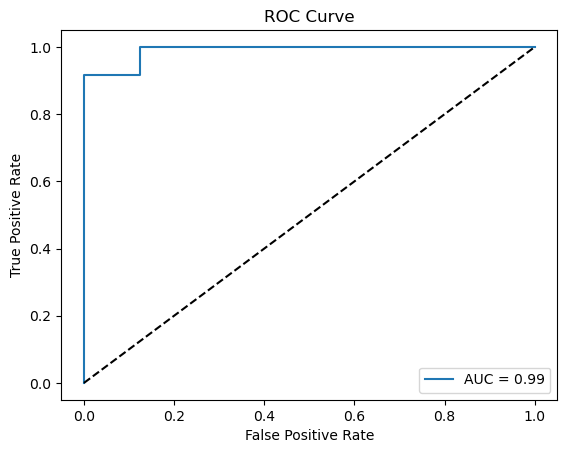

In [51]:
# train adder boost
asia =AdaBoostClassifier ( n_estimators = 100)
asia.fit(x_train_scaled, y_train)
y_pred = asia.predict(x_test_scaled)
acc = accuracy_score(y_test, y_pred)
print('acc of adder boost',acc)
cm = confusion_matrix (y_test, y_pred)

print("="*20)
print('confsn of adder',cm)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*20)
print("Recall  :", recall)
print("Precision  :", precision)
print("F1-score :", f1)

print("="*20)
report = classification_report(y_test, y_pred)
print(report)



y_probs = GG.predict_proba(x_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

acc of bagging boost 0.8
confsn of bagging [[7 1]
 [3 9]]
Recall  : 0.75
Precision  : 0.9
F1-score : 0.8181818181818182
              precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20

ROC-AUC: 0.9895833333333334


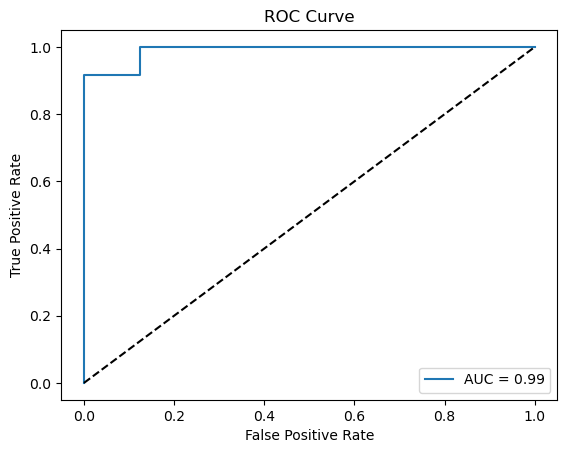

In [52]:
#  training by bagging boost
given = BaggingClassifier ( n_estimators = 100)
given.fit(x_train_scaled, y_train)
y_pred = given.predict(x_test_scaled)
acc = accuracy_score(y_test, y_pred)
print('acc of bagging boost',acc)
cm = confusion_matrix (y_test, y_pred)

print("="*20)
print('confsn of bagging',cm)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*20)
print("Recall  :", recall)
print("Precision  :", precision)
print("F1-score :", f1)

print("="*20)
report = classification_report(y_test, y_pred)
print(report)

y_probs = GG.predict_proba(x_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

acc of svc= 0.85
confsn of svc is [[8 0]
 [3 9]]
Recall  : 0.75
Precision  : 1.0
F1-score : 0.8571428571428571
              precision    recall  f1-score   support

           0       0.73      1.00      0.84         8
           1       1.00      0.75      0.86        12

    accuracy                           0.85        20
   macro avg       0.86      0.88      0.85        20
weighted avg       0.89      0.85      0.85        20

ROC-AUC: 0.9895833333333334


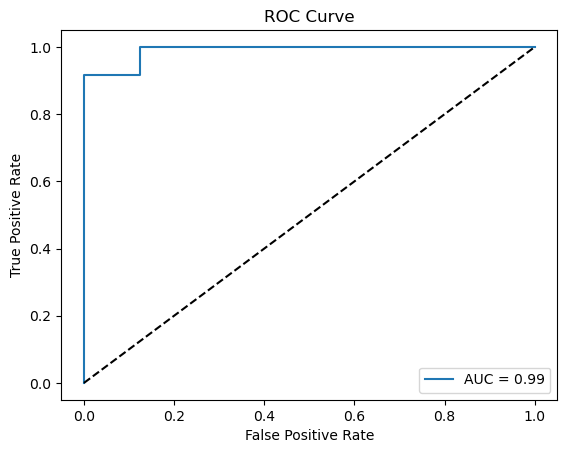

In [61]:
# trainging by svc
GG = SVC(probability=True, kernel='linear')  # or your chosen kernel
GG.fit(x_train_scaled, y_train)
y_pred = GG.predict(x_test_scaled)


acc = accuracy_score(y_test, y_pred)
print('acc of svc=',acc)
cm = confusion_matrix (y_test, y_pred)
print("="*20)
print('confsn of svc is',cm)

recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*20)
print("Recall  :", recall)
print("Precision  :", precision)
print("F1-score :", f1)

print("="*20)
report = classification_report(y_test, y_pred)
print(report)

y_probs = GG.predict_proba(x_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [64]:


# Create model instances instead of just referencing the classes
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "SVC": SVC()
}

results = []

for name, model in models.items():
    # First fit the model
    model.fit(x_train_scaled, y_train)  # Make sure to train the model first
    
    # Get predictions
    y_pred = model.predict(x_test_scaled)  # Now using the instance, not the class
    
    # If model has predict_proba, use probabilities
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(x_test_scaled)[:,1]
    else:
        # If it doesn't have predict_proba (like SVC without probability=True), use decision_function
        if hasattr(model, "decision_function"):
            y_probs = model.decision_function(x_test_scaled)
        else:
            y_probs = y_pred  # fallback
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_probs)
    
    results.append({"Model": name, "Accuracy": acc, "ROC-AUC": auc})

# Convert to DataFrame for better comparison
df_results = pd.DataFrame(results)
print(df_results)

               Model  Accuracy   ROC-AUC
0      Decision Tree      0.75  0.770833
1      Random Forest      0.80  0.958333
2  Gradient Boosting      0.80  0.958333
3           AdaBoost      0.85  0.958333
4            Bagging      0.85  0.932292
5                SVC      0.80  0.979167
